# J-lens readout on Qwen3-4B — pre-fitted lens vs logit lens

Does the Jacobian lens show the model's internal representations where the logit lens
does not? The lens is Anthropic's own, fitted by this library's `fit_lens.py` on 1000
WikiText-103 sequences and downloaded from `neuronpedia/jacobian-lens` — nothing is
fitted here. Readouts are scored over the 551 items of `data/evaluations`, whose
`intermediates` are the words the model must "think about" on the way to its answer but
does not say.

**Answer (this run, §6).** It depends on the question, and the conditioning turns out to
matter more than anything else. Over all 551 items the pre-fitted J-lens ranks the
intermediates *worse* than the logit lens at every k (pass@1 0.067 vs 0.132). But the model
answers only **41 of 255** targeted prompts correctly (§2c: multihop 24%, multilingual 18%,
order-ops **0%**), so most of that aggregate scores the lens on prompts the model cannot do.
Restricted to the three sets with a target and to the items it gets right (§4h), the two
lenses are close and the ordering flips with k: the logit lens leads at k=1 (0.255 vs 0.237)
while **J leads at k=10** (0.568 vs 0.560), and on multihop alone J leads clearly at k=10
(0.714 vs 0.619). J is also 5x better on `order-ops` at k=1 (0.091 vs 0.018) — the one set
the model never answers correctly.

Two caveats keep this from being a clean win. The J-lens's hits come from **late** layers:
restricted to the mid-depth workspace band it still loses badly even on correct answers
(0.039 vs 0.124 at k=1, §4h), and that band is where the paper says to read. And fuzzy
spelling matching (§4g) narrows the overall gap only slightly (J - logit from -0.065 to
-0.050 at k=1), so the shortfall is not a tokenization artifact. Qualitatively the lens
clearly does read internal content — at layer 24 of *"the country shaped like a boot"* its
top-1 is ` Italy`, the bridge entity, where the logit lens has it at rank 23 and still reads
` called` / ` currently` (§3a, and the slice pages in §3d). On the same model and lens,
`verbal_report.ipynb` reproduces the paper's Spearman metric (0.26 vs 0.13 at layer 12) and
`concept_swap.ipynb` reproduces the causal claim with logit-lens directions at exactly 0.000
in the early bands where J-lens directions reach 48%.

## Method

**Lens.** `lens(h) = unembed(J_l h)` with `J_l = E[d h_final / d h_l]` averaged over source
positions, later positions and a pretraining-like corpus. `J_l` is a fitted
`d_model x d_model` matrix per layer; applying it is one matmul, so the readout costs the
same as the logit lens. The logit-lens baseline is the same pipeline with `J_l = I`.

**Shared activations.** `jlens.evaluation.evaluate_paired` takes one forward pass per
prompt and reads both lenses off the same pre-final-norm block outputs, so the comparison
cannot be confounded by sampling or by a different forward.

**Scoring** (`data/evaluations/README.md`): at each layer a word's score is its 1-based
rank in the lens's vocabulary distribution at the dataset's readout position, min over
spellings. pass@k averages, within an item, the fraction of words whose best-over-layers
rank is <= k, then averages over items. `control` words are another item's intermediates
and give the chance baseline.

**Why this is the claim.** The intermediates are not in the prompt and not in the output.
A readout that ranks them highly is reporting something the model computed internally.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "workspace.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import gzip
import json
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.evaluation import (
    DATASETS,
    evaluate_paired,
    fuzzy_spelling_ids,
    identity_lens,
    jacobian_lens,
    layer_hit_rate,
    layer_median_rank,
    load_eval,
    logit_lens,
    pass_at_k,
    plot_layer_curves,
    readout_position,
    single_token_ids,
    spelling_ids,
)
from jlens.hooks import ActivationRecorder
from jlens.metrics import evaluate_distributions, lens_vector_geometry
from jlens.reference_plots import (
    intermediate_rank_sweep,
    plot_distribution_summary,
    plot_intermediate_sweep,
    plot_lens_comparison,
)
from jlens.vis import _meaningful_token_mask
from jlens.workspace import final_norm_centers

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3-4B")
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = {  # lenses fitted by this library's fit_lens.py on 1000 WikiText-103 x 128 tokens
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
}[MODEL_ID]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / SLUG))
RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)

# Qwen3 is RMSNorm, so lens directions carry no centering term; probed, not assumed.
CENTERS = final_norm_centers(model)
assert lens.d_model == model.d_model, (lens.d_model, model.d_model)
print(f"{model}  layout={model.layout.path}  centers={CENTERS}")
print(f"lens: {lens.n_prompts} prompts, layers {lens.source_layers[0]}-{lens.source_layers[-1]}")
print(f"tokenizer: bos_token_id={tokenizer.bos_token_id}  dtype={DTYPE}  device={DEVICE}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3ForCausalLM, n_layers=36, d_model=2560)  layout=model  centers=False
lens: 479 prompts, layers 0-34
tokenizer: bos_token_id=None  dtype=torch.bfloat16  device=cuda


In [5]:
LAYER_STRIDE = max(1, model.n_layers // 12)
# Pickled, not CSV: both frames carry per-layer numpy arrays in a single cell.
OUT_WORDS = RUN_DIR / "readout_words.pkl"
OUT_ITEMS = RUN_DIR / "readout_items.pkl"
OUT_WORDS_FUZZY = RUN_DIR / "readout_words_fuzzy.pkl"
# The mid-depth band the paper reads the workspace over, as fractions of depth.
WORKSPACE_BAND = list(range(round(0.33 * model.n_layers), round(0.78 * model.n_layers)))
# Recorded with the results, per AGENTS.md's Experiment Configuration.
RUN_INFO = {
    "model_id": MODEL_ID,
    "dtype": str(DTYPE),
    "device": DEVICE,
    "n_layers": model.n_layers,
    "d_model": model.d_model,
    "lens_file": LENS_FILE,
    "lens_n_prompts": lens.n_prompts,
    "lens_corpus": "Salesforce/wikitext wikitext-103-raw-v1, 128 tokens/sequence",
    "final_norm_centers": CENTERS,
    "transformers": __import__("transformers").__version__,
    "torch": torch.__version__,
}
RUN_INFO

{'model_id': 'Qwen/Qwen3-4B',
 'dtype': 'torch.bfloat16',
 'device': 'cuda',
 'n_layers': 36,
 'd_model': 2560,
 'lens_file': 'qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt',
 'lens_n_prompts': 479,
 'lens_corpus': 'Salesforce/wikitext wikitext-103-raw-v1, 128 tokens/sequence',
 'final_norm_centers': False,
 'transformers': '5.19.0',
 'torch': '2.14.0+cu126'}

## 1. Datasets

Six prompt sets from `data/evaluations`. Each item has a `prompt`, the `intermediates`
the model should pass through, and sometimes the `target` answer itself.

In [6]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}
print({dataset: len(items) for dataset, items in evals.items()})
print("total items:", sum(len(items) for items in evals.values()))
evals["multihop"][0]

{'multihop': 93, 'multilingual': 107, 'order-ops': 55, 'poetry': 98, 'association': 102, 'typo': 96}
total items: 551


{'name': 'carnival-ocean',
 'prompt': 'Fact: The ocean on the coast of the country where Carnival is most famously celebrated is the ',
 'target': 'Atlantic',
 'intermediates': ['Brazil']}

## 2. Sanity gates

Nothing below is worth reading unless these pass. The first checks that this adapter's
`unembed` really is the model's own head on this architecture; the second that the lens
machinery reduces exactly to the logit lens when `J_l = I`.

In [7]:
PROBE = "Fact: The currency used in the country shaped like a boot is"
ids = model.encode(PROBE)
with torch.no_grad():
    reference = hf_model(input_ids=ids).logits[0].float().cpu()
handwritten = logit_lens(model, PROBE)[-1].float().cpu()
rel_err = ((handwritten - reference).abs().max() / reference.abs().max()).item()
# bf16 carries ~3 decimal digits, so ~1e-3 is the noise floor here; a layout mistake
# (wrong norm, double unembed) would be O(1) and is what this gate is for.
GATE = 1e-4 if DTYPE == torch.float32 else 1e-2
print(f"unembed(final block) vs hf_model.logits: max rel err {rel_err:.2e}  (tol {GATE:g})")
assert rel_err < GATE, rel_err

unembed(final block) vs hf_model.logits: max rel err 0.00e+00  (tol 0.01)


In [8]:
identity = jacobian_lens(model, identity_lens(model), PROBE)
baseline = logit_lens(model, PROBE)
max_diff = (identity - baseline).abs().max().item()
print(f"identity lens vs logit lens: max abs diff {max_diff:.2e}")
assert max_diff < 1e-3, max_diff

identity lens vs logit lens: max abs diff 0.00e+00


### 2c. Does the model actually answer the question?

A readout metric is only interesting on prompts the model can do, so this measures that
first and independently of any lens: run the prompt, take the model's greedy next token at
the dataset's readout position, and compare it to the `target` under fuzzy matching (so
`' Italy'` and `'Italy'` both count).

Three of the six sets carry a `target`. `poetry`, `association` and `typo` do not, so
correctness is undefined for them and they are excluded from the correctness-conditioned
metric in §4h.

In [9]:
OUT_ANSWERS = RUN_DIR / "model_answers.csv"


@torch.no_grad()
def model_answers():
    rows = []
    for dataset, items_of in evals.items():
        for item in tqdm(items_of, desc=dataset, leave=False):
            if "target" not in item:
                continue
            prompt = item["prompt"].rstrip()
            ids = model.encode(prompt)
            position = readout_position(tokenizer, ids[0].tolist(), dataset)
            logits = hf_model(input_ids=ids).logits[0, position].float()
            accepted = sorted(fuzzy_spelling_ids(tokenizer, item["target"],
                                                 dataset == "order-ops"))
            top1 = int(logits.argmax())
            if accepted:
                index = torch.tensor(accepted, device=logits.device)
                rank = int((logits > logits[index].max()).sum()) + 1
            else:
                rank = None
            rows.append({"dataset": dataset, "item": item["name"],
                         "target": item["target"], "scorable": bool(accepted),
                         "model_top1": tokenizer.decode([top1]),
                         "target_rank": rank, "model_correct": top1 in set(accepted)})
    return pd.DataFrame(rows)


if OUT_ANSWERS.exists():
    answers = pd.read_csv(OUT_ANSWERS)
    print("loaded cached answers")
else:
    answers = model_answers()
    answers.to_csv(OUT_ANSWERS, index=False)

accuracy = answers.groupby("dataset").agg(
    accuracy=("model_correct", "mean"), items=("model_correct", "size"),
    scorable=("scorable", "sum")).round(3)
display(accuracy)
print("datasets without a target (accuracy undefined):",
      sorted(set(evals) - set(answers.dataset)))
CORRECT_ITEMS = set(map(tuple, answers.loc[answers.model_correct, ["dataset", "item"]].values))
print(f"{len(CORRECT_ITEMS)} of {len(answers)} targeted items answered correctly")

loaded cached answers


,accuracy,items,scorable
dataset,,,
multihop,0.237,93,87
multilingual,0.178,107,101
order-ops,0.000,55,55


datasets without a target (accuracy undefined): ['association', 'poetry', 'typo']
41 of 255 targeted items answered correctly


In [10]:
# What the model says when it is right and when it is wrong.
shown = []
for _, group in answers.groupby("dataset"):
    for correct in (True, False):
        subset = group[group.model_correct.eq(correct)]
        if not subset.empty:
            shown.append(subset.iloc[0])
display(pd.DataFrame(shown)[["dataset", "item", "target", "model_top1",
                             "target_rank", "model_correct"]]
        .set_index(["dataset", "model_correct"]))

item    target model_top1  target_rank
dataset      model_correct                                                        
multihop     True                 carnival-ocean  Atlantic   Atlantic          1.0
             False                    mars-color       red      green          3.0
multilingual True            japanese-day-monday       火曜日          火          1.0
             False          spanish-opposite-big   pequeño         pe          3.0
order-ops    False               parens-add-mult        20                  1038.0

## 3a. What the two lenses read at the readout position

The prompt needs *Italy* (shape -> country) to get to *euro* (country -> currency).
*Italy* is the internal step: it is in neither the prompt nor the answer.

In [11]:
jl = jacobian_lens(model, lens, PROBE)
ll = logit_lens(model, PROBE)
position = -1
rows = []
for layer in range(0, model.n_layers, LAYER_STRIDE):
    for name, logits in (("J-lens", jl), ("logit lens", ll)):
        top = logits[layer, position].topk(6).indices.tolist()
        rows.append({"layer": layer, "lens": name,
                     "top-6": " ".join(repr(tokenizer.decode([i])) for i in top)})
display(pd.DataFrame(rows).pivot(index="layer", columns="lens", values="top-6"))
print("model output:", [tokenizer.decode([i]) for i in jl[-1, position].topk(6).indices.tolist()])

lens,J-lens,logit lens
layer,,
0,' –' ' …\n\n' ' ….' '”.\n\n' '….\n\n' '’.\n\n','/is' 'lington' '館' 'rael' '紋' '该县'
3,'…”' '”\n' '.”\n' '…”\n\n' '”，' '”.\n\n','/is' 'ocratic' 'ucht' 'omers' 'rael' '-roll'
6,'`.\n\n' '”。\n\n' '`\n\n' '`.\n' '。\n\n' '”.\n\n','[number' 'もっと' '間違い' 'oven' '끔' 'ance'
9,' \\`' '`.\n\n' '`.\n' '`;\n\n' '帼' ' &#',' 물론' '끔' ' Федер' '全过程' '-but' '[number'
12,' \\`' '`.\n\n' '`.\n' ' […' ' Britain' '。\n','-shaped' ' shaped' '瘾' '_lib' '[number' 'ólica'
15,'吗' '。\\' '？\n' ' \\`' '哪个' '？\n\n','蓉' '-shaped' '地区的' '꼴' ' victories' '最多的'
18,'？\n' '？\n\n' ')?\n' '？”' ')?\n\n' '?”\n\n',' countries' '全国人民' ' located' ' namely' 'eder...
21,')?\n\n' ')?\n' '.*/\n' '?</' '?”\n\n' ';*/\n',' victories' ' where' '其中之一' ' one' '其中一个' ' f...
24,' Italy' '意大利' '欧元' '英镑' 'Italy' ' Italian',' called' ' currently' ' named' ' typically' '...


model output: [' the', ' called', ' ', ' Euro', '?\n', '欧元']


### 3b. The same readout across all six datasets

§3a is one prompt. This repeats it for one item from each set, at that set's own readout
position (`poetry` reads at the last newline, the rest at the last prompt token). Change
`PICK` to walk through other items — each set has 55-107 of them.

In [12]:
PICK = {"multihop": 0, "multilingual": 0, "order-ops": 0,
        "poetry": 0, "association": 0, "typo": 0}


def readout_table(dataset, index, top_n=6, layer_stride=None):
    #-layer top tokens of both lenses at this dataset's readout position.
    item = evals[dataset][index]
    prompt = item["prompt"].rstrip()
    ids = model.encode(prompt)[0].tolist()
    position = readout_position(tokenizer, ids, dataset)
    stride = layer_stride or LAYER_STRIDE
    jl_logits, ll_logits = jacobian_lens(model, lens, prompt), logit_lens(model, prompt)
    rows = []
    for layer in sorted({*range(0, model.n_layers, stride), model.n_layers - 1}):
        entry = {"layer": layer}
        for name, logits in (("J-lens", jl_logits), ("logit lens", ll_logits)):
            top = logits[layer, position].topk(top_n).indices.tolist()
            entry[name] = " ".join(repr(tokenizer.decode([i])) for i in top)
        rows.append(entry)
    return item, position, pd.DataFrame(rows).set_index("layer")


for dataset, index in PICK.items():
    item, position, table = readout_table(dataset, index)
    print("=" * 100)
    print(f"{dataset} / {item['name']}   readout position {position}")
    print(f"prompt: {item['prompt'].rstrip()!r}")
    print(f"intermediates: {item['intermediates']}   target: {item.get('target', '-')}")
    display(table)

multihop / carnival-ocean   readout position 17
prompt: 'Fact: The ocean on the coast of the country where Carnival is most famously celebrated is the'
intermediates: ['Brazil']   target: Atlantic


,J-lens,logit lens
layer,,
0,' ：' 's' '：\n' '：' ' \\\\' '：\n\n',"'館' 'öne' '<>(""' '<Texture' 'SPORT' 'vang'"
3,'”\n' '…\n' '…”' '.”\n' '，' '**\n','館' '<Texture' 'SPORT' 'enville' 'atron' 'ALLE'
6,'？\n\n' '。\n\n' '，' '？' '：\n\n' '：','款' 'cus' '\xadt' '结' 'tas' 'lí'
9,'？\n\n' '；' '！\n\n' '。\n\n' '：' '？','款' '吸引' '池' '湾' '仅次于' 'だ'
12,'海域' '海洋' '海岸' '海上' '海水' ' ocean','bay' ' area' ' basin' ' ocean' ' Ocean' ' water'
15,'海域' '海岸' '海洋' '海水' '岛屿' '海',' vast' ' bordered' '際' ' …\n\n' ' Ob' '_between'
18,'海域' '海岸' '海洋' ' coastal' '沿海' ' coastline',"' vast' ' ""' ' end' ' land' ' almost' ' largest'"
21,'海域' '海岸' '海洋' '地理' '沿海' '岛屿',"' land' '��' ' central' ' ""' ' most' 'land'"
24,' ocean' ' Ocean' '海域' '海岸' '海洋' ' coastal',' ocean' ' most' ' sea' ' same' ' surrounding'...


multilingual / spanish-opposite-big   readout position 9
prompt: 'Lo opuesto de "grande" es "'
intermediates: ['Spanish', 'opposite', 'big', 'small']   target: pequeño


,J-lens,logit lens
layer,,
0,"' ""\n\n' ' ""\n' ' ""\r\n' ' """"""\n\n' ' ""' ' the...","'...""' ' ""' '..."",' 'nels' '...""\n' ' "")""'"
3,"' ""\n' ' ""\r\n' ' ""\n\n' '""\n' '""\n\n' ' "".\n'","'+\'""' '!=""' '[]""' 'sth' 'lip' ""'-"""
6,"' ""\n' ' ""\r\n' ' ""\n\n' ' """"""\n\n' ' "".\n' ' ...",'形' '并' '“' 'ento' 'sth' '(es'
9,"' ""\n' ' ""\n\n' ' "".\n' '""\n\n' '.""\n\n' '"".\n\n'","'dale' '...""' '通讯员' 'ző' '_SPLIT' '...,'"
12,"'.""\n' '"".\n' '.""\n\n' '"".\n\n' '""\n' '...""\n'",'___' 'a' 'í' '____' '是什么' ' ____'
15,"'.""\n' '.""' '?""\n' '"".\n' '.""\n\n' '!""'",'____' ' ____' 'í' '是什么' '�' '\n\n'
18,"'?""\n' '""?' '?""' '.""\n' '.""' '...""'",'____' '___' ' ____' '是什么' ' ______' ' __'
21,"'""?' '?""' '.""' '?""\n\n' '?""\n' '.""\n\n'",'____' '___' ' ____' '什么呢' ' ______' ' __'
24,"'""?' '"",' '"".' '?"",' '"".\n' '?""\n'",'____' ' ____' '___' '________' '__' ' ______'


order-ops / parens-add-mult   readout position 9
prompt: '(2 + 3) * 4 ='
intermediates: ['5', 'multiplication']   target: 20


...

,J-lens,logit lens
layer,,
0,"' :\n' ' ,\n' ' \n' ' -\n' ' ;\n' ' \\\\\n'","',\n' '.,\n' 'sofar' '(),\n' '_,\n' ',\r\n'"
3,'：\n' '，\n' '。\n' '&\n' '@\n' '‘','audi' '白云' '(rc' 'upe' ' +=\n' 'urb'
6,"'\xa0\n' '，\n' ',\n' '。\n' '.,\n' '_,\n'","',\n' '""She' '(rc' 'ido' '.,\n' 'asin'"
9,"',\n' '，\n' ' -\n' ' ,\n' '\xa0\n' ' :\n'","'...\n' '这句话' ',\n' '...' '....\n' 'A'"
12,"'\xa0\n' '—""' '…\n' '—' ',\n' '\xa0'","'这句话' ',\n' '...\n' 'The' 'û' '\\\n'"
15,"'—""' '…\n' '—' '...\n' '…' '\xa0\n'","'这句话' 'grave' ',\n' 'utter' '_SF' ' followed'"
18,"'—""' '…""' '!’' '…”' '…' '…\n'","'这句话' '瞬间' 'The' 'utter' '这是' ',\n'"
21,' poetic' '诗意' '!’' '.’' ' haunting' '诗歌','The' 'Then' '瞬间' 'That' '_' ' then'
24,'__;\n' '__;' '_;\n' '__\n' '._\n' ' ______','The' 'Then' '___' ' ______' '________' '.\n'


association / grief   readout position 27
prompt: 'She kept his coffee mug on the counter, washed it every morning and put it back, though no one had used it in eleven months.'
intermediates: ['grief']   target: -


,J-lens,logit lens
layer,,
0,"'…\n' '…' '…\n\n' '•' ',…' ','",'館' 'しか' '銷' '<Texture' 'arton' '紋'
3,'。\n' '?\n' '…\n' ')?\n' '.\n' '?”','amed' 'amb' '另一半' 'lear' '紋' '-med'
6,'。\n' '。' '的' '没有' '这些' '没','–\n\n' '<Q' '也不会' '同样' '但却' '[])\r\n'
9,'后来' '当时的' '当时' ' However' '‗' '从未','他已经' '变得更加' 'imes' ' Palace' 'elden' 'ape'
12,'…\n' '…\n\n\n' ' […' '…\n\n' '.…' '…','背后的' '变得更加' '狂欢' 'енно' '_PULL' ' volunteered'
15,"'…""' '…it' '……' '…the' '…”' '…\n'",'我相信' 'ぬ' 'ycles' 'mó' ' düzen' '_behavior'
18,"'…""' '?""\n' '?\n' '？\n' '？' '……'",'没有必要' '不需要' '悠' '偏偏' ' unnecessary' '做的事情'
21,'为什么' '？' '？\n' '?’' '?”' '怎么',' why' '没有必要' ' unnecessary' '_behavior' ' wha...
24,'为什么' ' why' '为何' '怎么' '解释' ' Why',' why' '为什么' ' Why' 'Why' 'why' '为何'


typo / typo-language   readout position 10
prompt: 'The course required that every student learn a second langauge'
intermediates: ['language']   target: -


,J-lens,logit lens
layer,,
0,"' ：' '返回搜狐' ' ，' "" \\'"" '\\\\/' ' \\""'",'auge' 'aus' '不说' '瑛' '蜂蜜' 'ger'
3,' \n\n\n\n\n' ' \n \n' ' \n \n' ' \n...,'-language' '语言' ' languages' ' language' '(la...
6,"' ：' ' ，' ' ,[' ' english' ' spanish' "" \\'""",'kills' '普通话' ' franca' 'phon' 'yntax' ' Isl'
9,' english' ' spanish' ' ：' ' chinese' ' ，' ' o...,'和技术' ' franca' 'acro' '-symbol' '학' 'andin'
12,' spanish' ' english' '（' '翻译' '语言' '英语','外语' ' language' ' languages' ' flu' ' franca'...
15,' ，' ' english' '（' ' （' '翻译' '？',' flu' ' proficiency' 'yers' ' franca' '外语' ' ...
18,'？' '（' ' ，' '，' '．' ' 的',' spoken' 'yers' ' franca' ' proficiency' ' fl...
21,'．' '？' '，' '____' '。' '（',"'好不好' ' proficient' 'yers' ' spoken' '外语' ','"
24,'翻译' '语言' '．' '？' '，' '（',' proficiency' ' language' ' proficient' ' spo...


### 3c. Rank of the intermediate (` Italy`) and the target (` euro`) by layer

The J-lens should put *Italy* near the top somewhere in the middle of the network, and
the logit lens should not.

,J-lens ' Italy',logit ' Italy',J-lens ' euro',logit ' euro'
layer,,,,
0,3460,78124,13446,90489
3,30683,129393,111468,117113
6,65850,39784,28349,111576
9,105551,47597,23782,47327
12,152,1345,3757,108170
15,20484,4906,35383,20454
18,2439,7784,43223,13972
21,3988,976,42106,9334
24,1,24,75,256


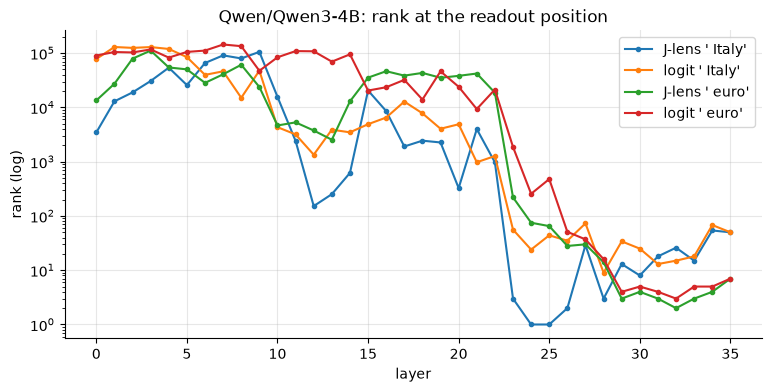

In [13]:
# 1-based rank of a word's first token at every layer.
def rank_of(logits, word, position=-1):
    ids = tokenizer.encode(word, add_special_tokens=False)
    scores = logits[:, position]
    return ((scores > scores[:, ids[0]].unsqueeze(-1)).sum(-1) + 1).cpu().numpy()

ranks = pd.DataFrame({
    "J-lens ' Italy'": rank_of(jl, " Italy"),
    "logit ' Italy'": rank_of(ll, " Italy"),
    "J-lens ' euro'": rank_of(jl, " euro"),
    "logit ' euro'": rank_of(ll, " euro"),
}, index=range(model.n_layers))
ranks.index.name = "layer"
display(ranks.iloc[::LAYER_STRIDE])
fig, ax = plt.subplots(figsize=(9, 4))
for column in ranks:
    ax.plot(ranks.index, ranks[column], marker=".", label=column)
ax.set_yscale("log")
ax.set_xlabel("layer")
ax.set_ylabel("rank (log)")
ax.set_title(f"{MODEL_ID}: rank at the readout position")
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### 3d. Position x layer slice — the paper's figure

The interactive view from the paper: a cell per (token position, layer) showing the lens's
top-1, with its full-vocabulary rank as a superscript. The bottom row (`L = n_layers - 1`)
is the model's own output. Click a cell to pin a token and track its rank everywhere.

`mask_display=True` restricts the *displayed* tokens to word-like ones and `alt_token`
glosses Qwen's CJK tokens into English — both exist in this repo because Qwen's raw top-K
is dominated by punctuation and CJK pieces (visible in §3a). Ranks stay full-vocabulary.

In [14]:
from jlens.vis import build_page, compute_slice, notebook_iframe

GLOSS = {int(k): v for k, v in
         json.loads(gzip.open(Path(REPO_DIR) / "assets/qwen_gloss.json.gz").read()).items()}
print(f"{len(GLOSS)} glossed token ids")


def slice_page(prompt, title, description, track=(), height=640, top_n=8, max_tracked=80):
    # max_tracked bounds the embedded rank tensor; without it the page dominates the
    # notebook's size (len(tracked) * seq_len * n_layers * 4 bytes before compression).
    pinned = {tokenizer.encode(" " + w, add_special_tokens=False)[0] for w in track}
    data = compute_slice(model, lens, prompt, top_n=top_n, max_tracked=max_tracked,
                         pinned_token_ids=pinned, layer_stride=LAYER_STRIDE,
                         mask_display=True)
    page, raw, payload = build_page(data, prompt, title=title, description=description,
                                   mode="embed", alt_token=GLOSS)
    print(f"{len(page) / 1e6:.2f} MB page, {len(data.tracked_token_ids)} tracked tokens")
    return notebook_iframe(page, height=height)


slice_page(PROBE, title="J-lens on Qwen3-4B",
           description="Two-hop: shape -> Italy -> euro. Pinned: Italy, euro.",
           track=("Italy", "euro"))

91695 glossed token ids


0.41 MB page, 80 tracked tokens


In [15]:
two_hop = evals["multihop"][PICK["multihop"]]
slice_page(two_hop["prompt"].rstrip(),
           title=f"J-lens: multihop / {two_hop['name']}",
           description=f"intermediates {two_hop['intermediates']}, "
                       f"target {two_hop.get('target', '-')}",
           track=tuple(two_hop["intermediates"]) + ((two_hop["target"],)
                                                    if "target" in two_hop else ()))

0.43 MB page, 81 tracked tokens


## 4. All 551 items

One forward pass per prompt, both lenses off the same activations. Cached to CSV, so
re-executing the notebook does not repeat it.

In [16]:
if OUT_WORDS.exists() and OUT_ITEMS.exists():
    words, items = pd.read_pickle(OUT_WORDS), pd.read_pickle(OUT_ITEMS)
    print("loaded cached readouts")
else:
    words, items = evaluate_paired(model, lens, evals)
    words.to_pickle(OUT_WORDS)
    items.to_pickle(OUT_ITEMS)
print(len(words), "word rows,", len(items), "item rows")
words.head(3)

loaded cached readouts
4186 word rows, 1102 item rows


,dataset,item,kind,word,role,single_token,in_prompt,ranks,best_rank,best_layer,lens
0,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[4570, 7883, 3354, 11453, 25460, 95638, 51532,...",110,35,logit lens
1,multihop,carnival-ocean,control,China,0,True,False,"[42787, 39936, 54264, 89467, 84664, 85935, 295...",780,20,logit lens
2,multihop,carnival-ocean,target,Atlantic,0,True,False,"[49188, 43430, 42833, 62462, 60789, 21068, 192...",1,28,logit lens


### 4a. pass@k over all words, by kind

In [17]:
scores = pass_at_k(words)
display(scores.pivot_table(index=["dataset", "kind"], columns=["lens", "k"], values="score").round(3))

lens                      J-lens                      logit lens                     
k                            1      5      10     100        1      5      10     100
dataset      kind                                                                    
association  control       0.000  0.000  0.000  0.010      0.000  0.010  0.010  0.049
             intermediate  0.000  0.000  0.020  0.098      0.010  0.020  0.029  0.137
multihop     control       0.033  0.054  0.065  0.217      0.033  0.054  0.065  0.293
             intermediate  0.161  0.376  0.484  0.774      0.215  0.360  0.446  0.808
             target        0.441  0.591  0.624  0.774      0.452  0.613  0.677  0.882
multilingual control       0.000  0.006  0.009  0.055      0.005  0.024  0.027  0.058
             intermediate  0.201  0.329  0.383  0.579      0.215  0.369  0.460  0.659
             target        0.467  0.673  0.757  0.925      0.374  0.673  0.729  0.907
order-ops    control       0.010  0.020  0.110  0.650      0.010  0.020  0.110  0.690
             intermediate  0.009  0.100  0.255  0.709      0.027  0.136  0.255  0.764
             target        0.036  0.055  0.073  0.564      0.036  0.055  0.073  0.618
poetry       control       0.000  0.000  0.010  0.071      0.010  0.010  0.031  0.102
             intermediate  0.000  0.010  0.020  0.112      0.000  0.010  0.020  0.194
typo         control       0.000  0.000  0.000  0.042      0.000  0.000  0.010  0.094
             intermediate  0.031  0.250  0.323  0.740      0.323  0.604  0.750  0.958

### 4b. Intermediates only — the headline comparison

`control` is the chance baseline (another item's intermediates), so the number that
matters is intermediate minus control, J-lens vs logit lens.

In [18]:
summary = (pass_at_k(words)
           .pivot_table(index=["kind", "k"], columns="lens", values="score")
           .round(3))
summary["J - logit"] = (summary["J-lens"] - summary["logit lens"]).round(3)
display(summary)

lens              J-lens  logit lens  J - logit
kind         k                                 
control      1     0.007       0.010     -0.003
             5     0.013       0.020     -0.007
             10    0.032       0.042     -0.010
             100   0.174       0.214     -0.040
intermediate 1     0.067       0.132     -0.065
             5     0.178       0.250     -0.072
             10    0.247       0.327     -0.080
             100   0.502       0.587     -0.085
target       1     0.315       0.287      0.028
             5     0.440       0.447     -0.007
             10    0.484       0.493     -0.009
             100   0.754       0.802     -0.048

### 4c. Restricted to the workspace band

pass@k above takes the best rank over *all* layers, which flatters the logit lens: at the
last layers it is the model's own output distribution. The paper reads the workspace over a
mid-depth band instead (`data/evaluations/README.md`), so this repeats the comparison with
only those layers available to both lenses.

In [19]:
print("band layers:", WORKSPACE_BAND[0], "-", WORKSPACE_BAND[-1])
band = (pass_at_k(words, layers=WORKSPACE_BAND)
        .pivot_table(index=["kind", "k"], columns="lens", values="score")
        .round(3))
band["J - logit"] = (band["J-lens"] - band["logit lens"]).round(3)
display(band)

band layers: 12 - 27


lens              J-lens  logit lens  J - logit
kind         k                                 
control      1     0.000       0.004     -0.004
             5     0.000       0.009     -0.009
             10    0.000       0.014     -0.014
             100   0.034       0.127     -0.093
intermediate 1     0.013       0.069     -0.056
             5     0.078       0.152     -0.074
             10    0.108       0.219     -0.111
             100   0.267       0.482     -0.215
target       1     0.022       0.035     -0.013
             5     0.091       0.105     -0.014
             10    0.129       0.156     -0.027
             100   0.249       0.400     -0.151

In [20]:
display(pass_at_k(words[words.kind.eq("intermediate")], layers=WORKSPACE_BAND)
        .pivot_table(index="dataset", columns=["lens", "k"], values="score").round(3))

lens         J-lens                      logit lens                     
k               1      5      10     100        1      5      10     100
dataset                                                                 
association   0.000  0.000  0.000  0.049      0.010  0.010  0.010  0.088
multihop      0.022  0.151  0.204  0.419      0.086  0.199  0.231  0.625
multilingual  0.058  0.129  0.161  0.376      0.089  0.241  0.348  0.593
order-ops     0.000  0.000  0.000  0.155      0.018  0.045  0.118  0.609
poetry        0.000  0.000  0.000  0.041      0.000  0.010  0.010  0.071
typo          0.000  0.188  0.281  0.562      0.208  0.406  0.594  0.906

### 4d. Is the gap an artifact of Qwen's vocabulary?

The J-lens readout is visibly full of CJK tokens and punctuation (§3), and a full-vocabulary
rank punishes that even where the right concept is present. `jlens.vis` already has the mask
used for display (`mask_display=True`); here it is applied to the *ranks*, over the two
datasets where both lenses do best. If the J-lens only looked worse because of non-word
tokens, masking would close the gap.

In [21]:
wordlike = _meaningful_token_mask(tokenizer, model._lm_head.weight.shape[0], model.input_device)
print(f"word-like tokens: {int(wordlike.sum())} of {wordlike.numel()}")

rows = []
for dataset in ("multihop", "multilingual"):
    for item in evals[dataset]:
        prompt = item["prompt"].rstrip()
        ids = model.encode(prompt)
        position = readout_position(tokenizer, ids[0].tolist(), dataset)
        with torch.no_grad(), ActivationRecorder(model.layers, at=WORKSPACE_BAND) as recorder:
            model.forward(ids)
            acts = {l: recorder.activations[l].detach() for l in WORKSPACE_BAND}
        for word in item["intermediates"]:
            ids_of_word = sorted(spelling_ids(tokenizer, word))
            if not ids_of_word:
                continue
            index = torch.tensor(ids_of_word, device=model.input_device)
            best = {"J-lens": (10**9, 10**9), "logit lens": (10**9, 10**9)}
            for layer in WORKSPACE_BAND:
                h = acts[layer][0, position].float()
                for name, residual in (("J-lens", lens.transport(h, layer)), ("logit lens", h)):
                    logits = model.unembed(residual).float()
                    full = int((logits > logits[index].max()).sum()) + 1
                    masked_logits = logits.masked_fill(~wordlike, -float("inf"))
                    masked = int((masked_logits > masked_logits[index].max()).sum()) + 1
                    best[name] = (min(best[name][0], full), min(best[name][1], masked))
            for name, (full, masked) in best.items():
                rows.append({"dataset": dataset, "lens": name, "full": full, "masked": masked})

masked_ranks = pd.DataFrame(rows)
table = pd.concat(
    {f"@{k}": masked_ranks.assign(full_hit=masked_ranks.full <= k, masked_hit=masked_ranks.masked <= k)
     .groupby(["dataset", "lens"])[["full_hit", "masked_hit"]].mean()
     for k in (1, 5, 10)}, axis=1).round(3)
display(table)

word-like tokens: 121220 of 151936


@1                  @5                 @10           
                        full_hit masked_hit full_hit masked_hit full_hit masked_hit
dataset      lens                                                                  
multihop     J-lens        0.019      0.019    0.136      0.146    0.184      0.214
             logit lens    0.078      0.078    0.184      0.194    0.214      0.214
multilingual J-lens        0.058      0.114    0.129      0.241    0.161      0.320
             logit lens    0.089      0.133    0.241      0.315    0.348      0.390

### 4e. Where in depth does each lens find the intermediates?

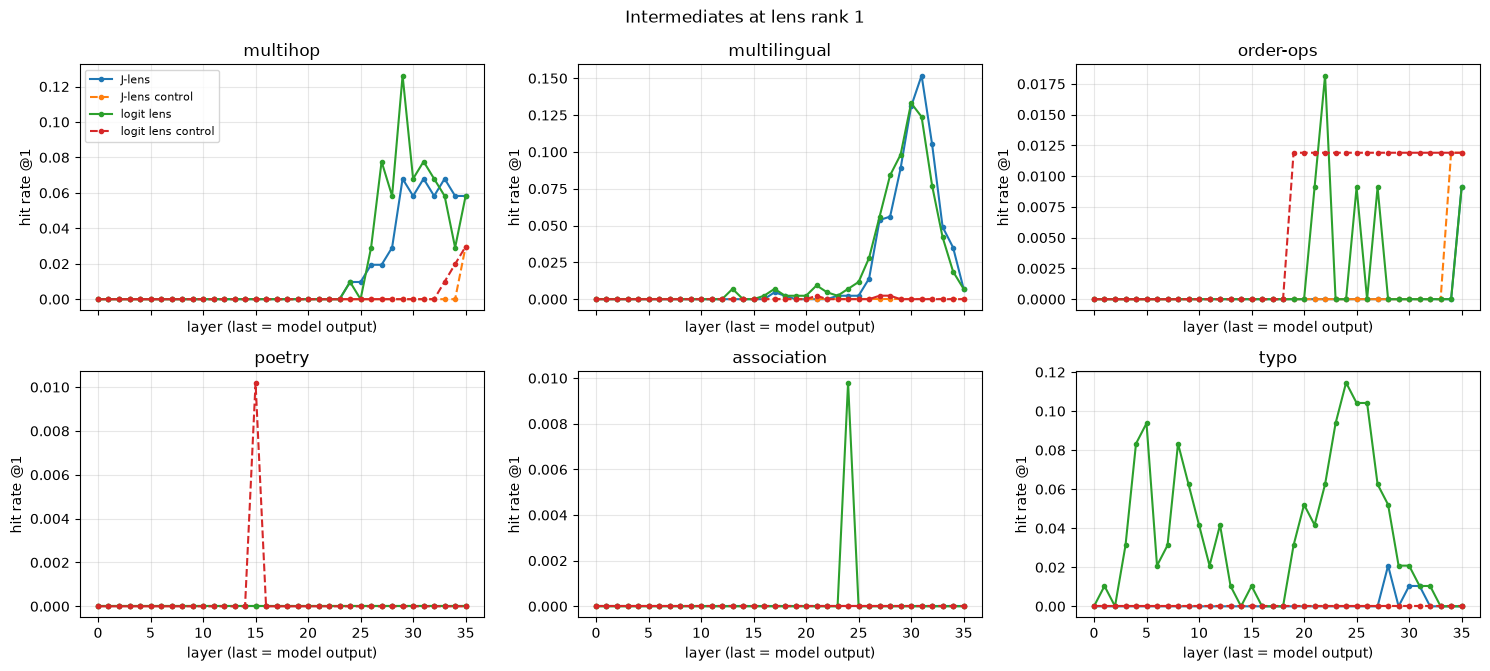

In [22]:
hits, medians = {}, {}
for name in ("J-lens", "logit lens"):
    for kind in ("intermediate", "control"):
        subset = words[words.lens.eq(name) & words.kind.eq(kind)]
        label = name if kind == "intermediate" else f"{name} control"
        hits[label] = layer_hit_rate(subset, k=1)
        medians[label] = layer_median_rank(subset)
plot_layer_curves(hits, "Intermediates at lens rank 1", "hit rate @1")
plt.show()

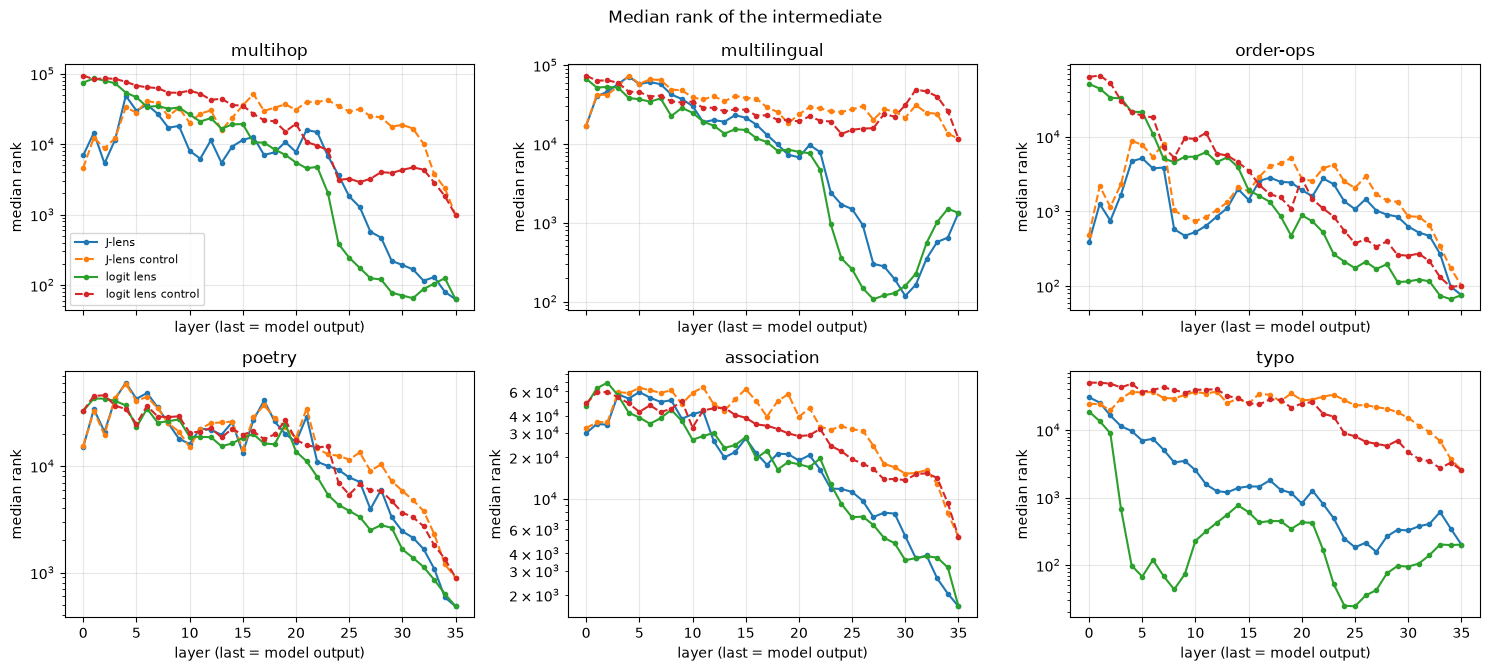

In [23]:
plot_layer_curves(medians, "Median rank of the intermediate", "median rank", logy=True)
plt.show()

### 4f. Figure 52 adaptation: intermediate rank sweep over k

lens,J-lens,logit lens
dataset,,
association,0.023,0.046
multihop,0.475,0.485
multilingual,0.400,0.461
order-ops,0.293,0.299
poetry,0.036,0.041
typo,0.332,0.690


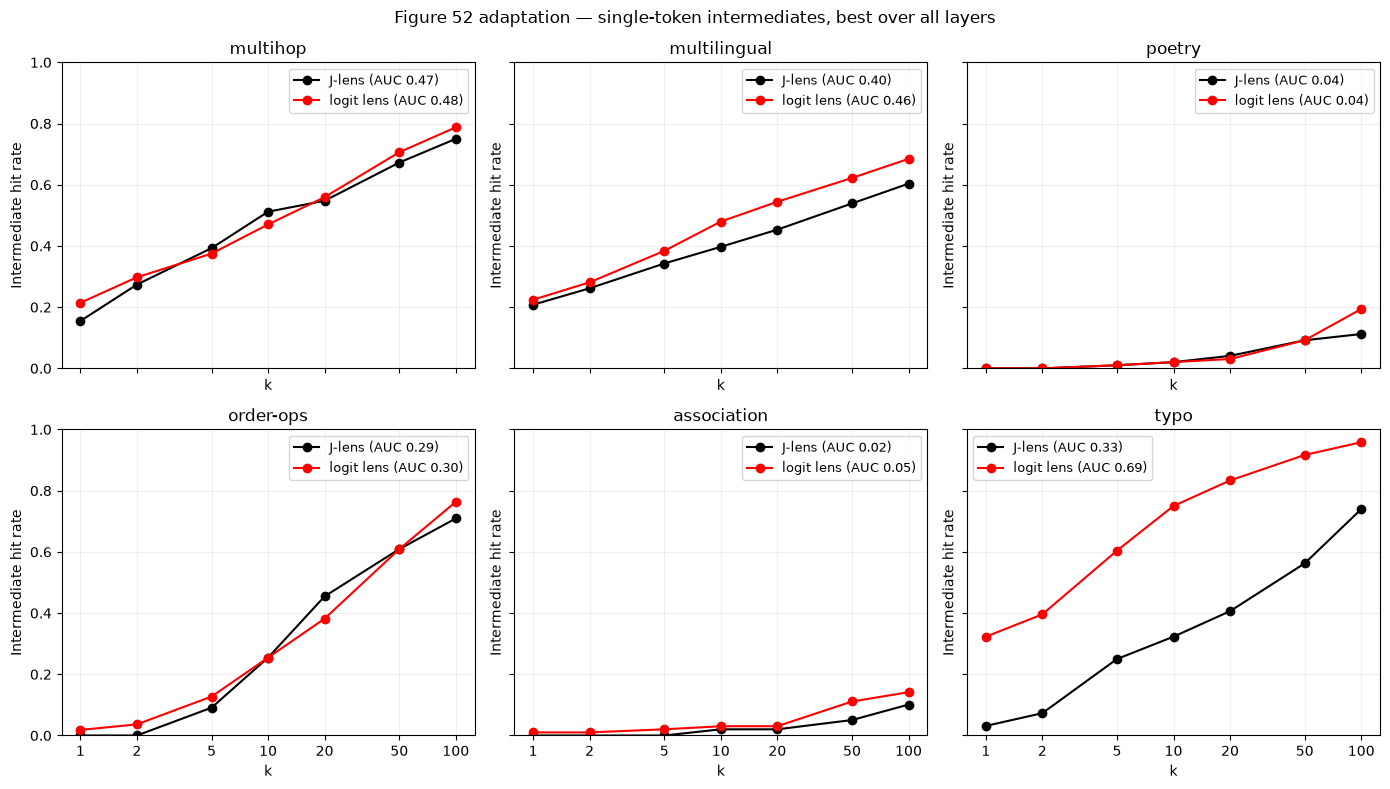

In [24]:
sweep = intermediate_rank_sweep(words)
# AUC is trapezoidal in log(k), normalised by log(k_max/k_min): one number per lens/task.
display(sweep.scores.pivot_table(index="dataset", columns="lens", values="auc").round(3))
plot_intermediate_sweep(sweep)
plt.show()

### 4g. Fuzzy spelling match

Scoring a word means deciding which token ids count as the model saying it, and on Qwen
that is not straightforward. `jlens.evaluation.fuzzy_spelling_ids` has three arms:

1. **Exact** — every vocabulary token whose decoded text equals the word ignoring
   surrounding whitespace and case, so `' Italy'` and `'Italy'` are one answer. This is a
   superset of the default `single_token_ids`, which can only construct variants it
   guesses at; the full-vocabulary scan finds the rest.
2. **Prefix** — for a word with no single-token form, the first token of its own
   tokenization, accepted only when that decodes to a non-whitespace prefix of at least
   two characters (or one, if non-ASCII, since a CJK token carries much more of the word).
   This is what makes `tellurium`, `automne` and `火曜日` scorable at all.
3. **Unscorable** — otherwise nothing, and the word is *excluded*. The default
   `spelling_ids` instead falls back to the first token of `" word"`, which for a Qwen
   numeral is a bare space: a very common next token that scores as a hit whenever the
   continuation happens to be whitespace.

The prefix arm raises absolute hit rates for both lenses, so the strict and fuzzy runs are
reported side by side rather than one replacing the other.

In [25]:
coverage = []
for dataset, items_of in evals.items():
    for item in items_of:
        pairs = [("intermediate", w) for w in item["intermediates"]]
        if "target" in item:
            pairs.append(("target", item["target"]))
        for kind, word in pairs:
            expand = dataset == "order-ops"
            strict = sorted(spelling_ids(tokenizer, word, expand))
            exact = fuzzy_spelling_ids(tokenizer, word, expand, prefix=False)
            full = fuzzy_spelling_ids(tokenizer, word, expand)
            coverage.append({
                "dataset": dataset, "kind": kind, "word": word,
                "exact adds vs single_token_ids": len(exact - single_token_ids(tokenizer, word, expand)) > 0,
                "rescued by prefix": not exact and bool(full),
                "unscorable": not full,
                "strict was whitespace-only": bool(strict) and all(
                    not tokenizer.decode([i]).strip() for i in strict),
            })
coverage = pd.DataFrame(coverage)
display(coverage.groupby("dataset")[[
    "exact adds vs single_token_ids", "rescued by prefix", "unscorable",
    "strict was whitespace-only"]].sum())
print("spot checks:")
for word in ("Italy", "tellurium", "automne", "火曜日", "26"):
    got = sorted(fuzzy_spelling_ids(tokenizer, word))
    print(f"  {word!r:12} -> {[repr(tokenizer.decode([i])) for i in got] or 'UNSCORABLE'}")

,exact adds vs single_token_ids,rescued by prefix,unscorable,strict was whitespace-only
dataset,,,,
association,30,1,2,0
multihop,49,1,15,15
multilingual,221,62,6,0
order-ops,95,3,0,3
poetry,66,0,0,0
typo,57,0,0,0


spot checks:
  'Italy'      -> ["' Italy'", "'Italy'"]
  'tellurium'  -> ["' tell'"]
  'automne'    -> ["' autom'"]
  '火曜日'        -> ["'火'"]
  '26'         -> UNSCORABLE


In [26]:
if OUT_WORDS_FUZZY.exists():
    words_fuzzy = pd.read_pickle(OUT_WORDS_FUZZY)
    print("loaded cached fuzzy readouts")
else:
    words_fuzzy, _ = evaluate_paired(
        model, lens, evals, "paired lenses (fuzzy)",
        spelling_lookup=partial(fuzzy_spelling_ids, tokenizer),
    )
    words_fuzzy.to_pickle(OUT_WORDS_FUZZY)
# Unscorable words carry ranks=None and must be dropped before pass_at_k stacks them.
scored_fuzzy = words_fuzzy[words_fuzzy.ranks.notna()]
print(f"{len(scored_fuzzy)} of {len(words_fuzzy)} word rows scorable under fuzzy matching")

loaded cached fuzzy readouts
4118 of 4186 word rows scorable under fuzzy matching


In [27]:
def intermediate_summary(frame, label):
    table = (pass_at_k(frame[frame.kind.eq("intermediate")])
             .pivot_table(index="k", columns="lens", values="score").round(3))
    table["J - logit"] = (table["J-lens"] - table["logit lens"]).round(3)
    return table.assign(matching=label).set_index("matching", append=True)


display(pd.concat([
    intermediate_summary(words, "strict (spelling_ids)"),
    intermediate_summary(scored_fuzzy, "fuzzy (exact + prefix)"),
]).reorder_levels(["matching", "k"]).sort_index())

lens                        J-lens  logit lens  J - logit
matching               k                                 
fuzzy (exact + prefix) 1     0.080       0.130     -0.050
                       5     0.191       0.251     -0.060
                       10    0.268       0.329     -0.061
                       100   0.503       0.583     -0.080
strict (spelling_ids)  1     0.067       0.132     -0.065
                       5     0.178       0.250     -0.072
                       10    0.247       0.327     -0.080
                       100   0.502       0.587     -0.085

In [28]:
display(pd.concat([
    pass_at_k(words[words.kind.eq("intermediate")]).assign(matching="strict"),
    pass_at_k(scored_fuzzy[scored_fuzzy.kind.eq("intermediate")]).assign(matching="fuzzy"),
]).pivot_table(index=["dataset", "matching"], columns=["lens", "k"], values="score").round(3))

lens                  J-lens                      logit lens                     
k                        1      5      10     100        1      5      10     100
dataset      matching                                                            
association  fuzzy     0.000  0.000  0.020  0.100      0.010  0.020  0.030  0.140
             strict    0.000  0.000  0.020  0.098      0.010  0.020  0.029  0.137
multihop     fuzzy     0.155  0.393  0.512  0.750      0.214  0.375  0.470  0.788
             strict    0.161  0.376  0.484  0.774      0.215  0.360  0.446  0.808
multilingual fuzzy     0.201  0.329  0.383  0.579      0.215  0.369  0.460  0.661
             strict    0.201  0.329  0.383  0.579      0.215  0.369  0.460  0.659
order-ops    fuzzy     0.091  0.164  0.336  0.727      0.018  0.127  0.245  0.755
             strict    0.009  0.100  0.255  0.709      0.027  0.136  0.255  0.764
poetry       fuzzy     0.000  0.010  0.020  0.112      0.000  0.010  0.020  0.194
             strict    0.000  0.010  0.020  0.112      0.000  0.010  0.020  0.194
typo         fuzzy     0.031  0.250  0.333  0.750      0.323  0.604  0.750  0.958
             strict    0.031  0.250  0.323  0.740      0.323  0.604  0.750  0.958

### 4h. All questions vs correctly answered questions only

If the J-lens readout reflects a computation the model actually carried out, it should look
better on the items the model gets right. Restricted to the three sets with a `target`
(§2c), scored with fuzzy matching.

In [29]:
WITH_TARGET = sorted(set(answers.dataset))
print("datasets with a target:", WITH_TARGET)

scoped = scored_fuzzy[scored_fuzzy.dataset.isin(WITH_TARGET)]
keys = list(zip(scoped.dataset, scoped.item, strict=True))
only_correct = scoped[[key in CORRECT_ITEMS for key in keys]]
print(f"{len(set(keys))} items in scope, {len(CORRECT_ITEMS)} answered correctly")

splits = {"all questions": scoped, "correct answers only": only_correct}
display(pd.concat([
    pass_at_k(frame[frame.kind.eq("intermediate")]).assign(subset=label)
    for label, frame in splits.items()
]).pivot_table(index=["subset", "k"], columns="lens", values="score").round(3))

datasets with a target: ['multihop', 'multilingual', 'order-ops']
255 items in scope, 41 answered correctly


lens                      J-lens  logit lens
subset               k                      
all questions        1     0.149       0.149
                     5     0.295       0.290
                     10    0.410       0.392
                     100   0.686       0.734
correct answers only 1     0.237       0.255
                     5     0.416       0.431
                     10    0.568       0.560
                     100   0.657       0.758

In [30]:
display(pd.concat([
    pass_at_k(frame[frame.kind.eq("intermediate")]).assign(subset=label)
    for label, frame in splits.items()
]).pivot_table(index=["dataset", "subset"], columns=["lens", "k"], values="score").round(3))

lens                              J-lens                      logit lens                     
k                                    1      5      10     100        1      5      10     100
dataset      subset                                                                          
multihop     all questions         0.155  0.393  0.512  0.750      0.214  0.375  0.470  0.788
             correct answers only  0.238  0.476  0.714  0.762      0.286  0.429  0.619  0.857
multilingual all questions         0.201  0.329  0.383  0.579      0.215  0.369  0.460  0.661
             correct answers only  0.237  0.355  0.421  0.553      0.224  0.434  0.500  0.658
order-ops    all questions         0.091  0.164  0.336  0.727      0.018  0.127  0.245  0.755

In [31]:
# Same split over the workspace band, where the paper reads the workspace.
display(pd.concat([
    pass_at_k(frame[frame.kind.eq("intermediate")], layers=WORKSPACE_BAND).assign(subset=label)
    for label, frame in splits.items()
]).pivot_table(index=["subset", "k"], columns="lens", values="score").round(3))

lens                      J-lens  logit lens
subset               k                      
all questions        1     0.027       0.067
                     5     0.098       0.162
                     10    0.136       0.234
                     100   0.392       0.602
correct answers only 1     0.039       0.124
                     5     0.174       0.305
                     10    0.259       0.364
                     100   0.483       0.684

## 5. Held-out distribution metrics (Figures 55/56 adaptations)

How far each layer's readout is from the model's own output distribution, on held-out
text rather than the evaluation prompts. These are the repo's adaptations, not numbers
the paper reports.

In [32]:
HELD_OUT = [item["prompt"] for dataset in ("poetry", "association") for item in evals[dataset][:24]]
distributions = evaluate_distributions(model, lens, HELD_OUT,
                                       layers=list(range(0, model.n_layers, LAYER_STRIDE)))
display(distributions.layers.round(4))

held-out lens metrics:   0%|          | 0/48 [00:00<?, ?it/s]

,lens,layer,is_final,kl_model_to_lens,entropy,top1_agreement,n_tokens,n_texts,n_texts_used,weighting
0,logit lens,0,False,18.1894,3.1804,0.0000,1254,48,48,token
1,logit lens,3,False,15.5481,5.4668,0.0000,1254,48,48,token
2,logit lens,6,False,11.2655,7.0048,0.0024,1254,48,48,token
3,logit lens,9,False,10.2869,6.6568,0.0048,1254,48,48,token
4,logit lens,12,False,9.0175,6.9275,0.0120,1254,48,48,token
5,logit lens,15,False,8.4575,7.1727,0.0104,1254,48,48,token
6,logit lens,18,False,6.8341,7.1548,0.0215,1254,48,48,token
7,logit lens,21,False,5.9010,6.4940,0.0702,1254,48,48,token
8,logit lens,24,False,4.3025,3.9404,0.1411,1254,48,48,token
9,logit lens,27,False,3.3852,2.8436,0.2432,1254,48,48,token


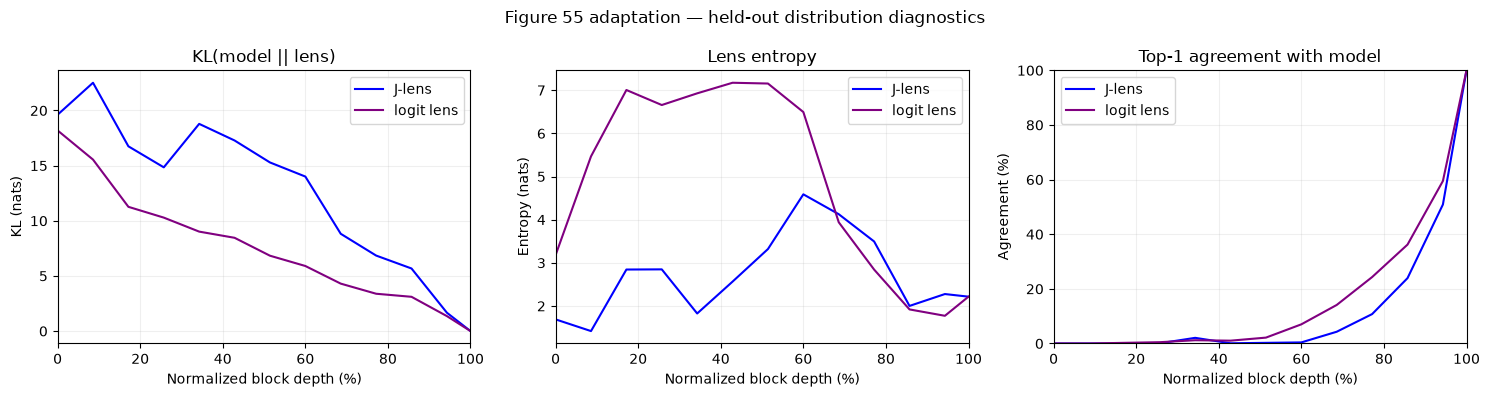

In [33]:
plot_distribution_summary(distributions.layers, n_layers=model.n_layers)
plt.show()

lens vector geometry:   0%|          | 0/13 [00:00<?, ?it/s]

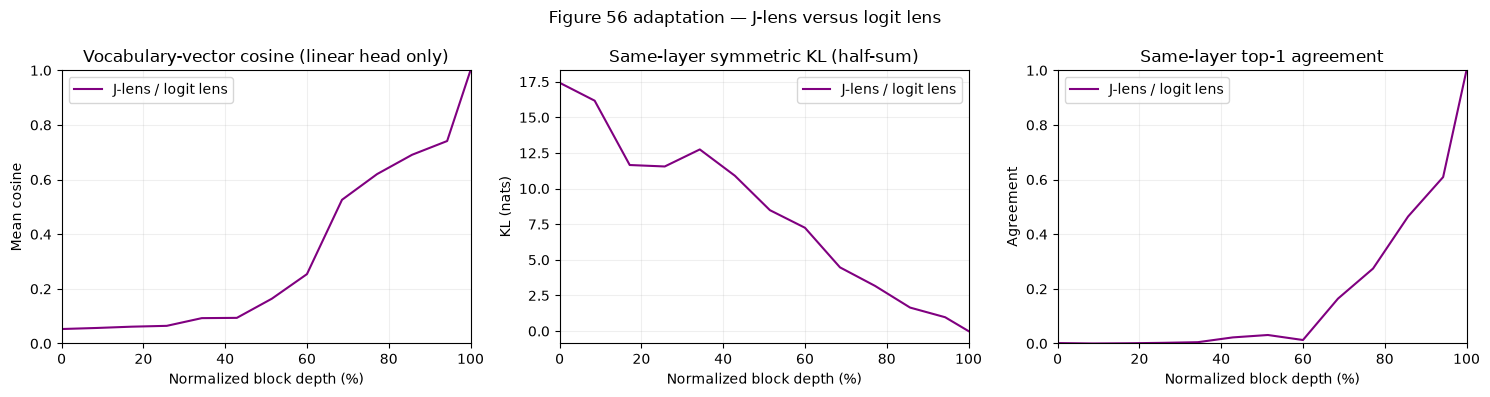

,layer,is_final,status,reason,mean_cosine,n_vocab,n_valid_vectors,n_zero_vectors,weighting,convention
0,0,False,ok,,0.0530,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
1,3,False,ok,,0.0568,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
2,6,False,ok,,0.0616,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
3,9,False,ok,,0.0646,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
4,12,False,ok,,0.0928,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
5,15,False,ok,,0.0938,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
6,18,False,ok,,0.1641,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
7,21,False,ok,,0.2540,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
8,24,False,ok,,0.5261,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
9,27,False,ok,,0.6201,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J


In [34]:
geometry = lens_vector_geometry(model, lens, layers=list(range(0, model.n_layers, LAYER_STRIDE)))
plot_lens_comparison(distributions.pairs, geometry, n_layers=model.n_layers)
plt.show()
display(geometry.round(4))

## 6. Conclusions

* **Conditioning on what the model can actually do changes the verdict.** Unconditioned,
  over 551 items, the J-lens loses at every k (pass@1 0.067 vs 0.132, §4b). Conditioned on
  the three sets with a target and on correct answers, both lenses roughly double and the gap
  closes: 0.237 vs 0.255 at k=1 and **0.568 vs 0.560 at k=10**, with J ahead on multihop at
  k=10 (0.714 vs 0.619). The blanket negative was driven mostly by `typo` — where the
  intermediates are corrected spellings of tokens already in the prompt, so the logit lens
  reads them straight off the residual stream (0.031 vs 0.344) — and by the 84% of targeted
  prompts the model gets wrong.
* **The model is the bottleneck, not the lens.** Qwen3-4B answers 24% of multihop, 18% of
  multilingual and **0%** of order-ops (§2c). On order-ops it predicts whitespace at the
  readout position on every single item, which is a prompt-format mismatch rather than a
  reasoning failure. A readout cannot show a computation the model never performed, so an
  aggregate over these sets is largely measuring the model.
* **But the J-lens's advantage is not in the workspace band.** Restricted to layers 12-27,
  the band the paper reads, the logit lens still wins decisively even on correct answers
  (0.039 vs 0.124 at k=1; 0.259 vs 0.364 at k=10, §4h). The J-lens's hits come from late
  layers, where `J_l` is already close to the identity (cos(W_U, W_U J_l) = 0.53 at layer 24,
  0.74 at 33, §5). That is the plain Jacobian lens's known early-layer weakness, and the
  stated motivation for the later J++ variant, which is deliberately not used here.
* **It is not a tokenization artifact.** Fuzzy matching (§4g) adds ids for 518 words, rescues
  67 multi-token words the strict matcher could not score at all (`tellurium`, `automne`,
  `火曜日`), and removes 18 cases where the strict fallback matched a **bare space** on Qwen
  numerals. It moves J - logit from -0.065 to -0.050 at k=1: real, but far short of
  explaining the gap. Masking the readout to word-like tokens (§4d) does not close it either.
* **The lens is nevertheless reading internal content.** §3a-3d: at layer 24 the J-lens's
  top-1 is the bridge entity ` Italy`, present in neither prompt nor answer, while the logit
  lens reads function words. The slice pages make that inspectable position by position, and
  §7 lets you check it on your own prompts — including the nonsense control, where neither
  lens should look confident.
* **The paper's main evidence is causal, and it does reproduce.** `concept_swap.ipynb` gets
  48-51% swap success against 1-3% for norm-matched random directions, with logit-lens
  directions at exactly 0.000 in the early bands; `verbal_report.ipynb` reproduces the
  paper's Spearman metric with the J-lens ahead at every layer tested. A lens can carry a
  causally effective direction without winning a full-vocabulary rank contest.
* **Caveats.** One model, one lens, one fit corpus (479 WikiText prompts by this lens's own
  convergence record). The correctness-conditioned cells rest on 41 items, so those numbers
  are indicative, not tight. Ranks are tokenizer-dependent and not comparable to the repo's
  GPT-2 runs. The prefix arm of fuzzy matching raises absolute hit rates for both lenses
  equally, so lens-vs-lens contrasts stay fair but absolute values are not comparable to a
  strict run. bf16 throughout, matching the dtype the lens was fitted in.

## 7. Play with the lens yourself

Everything above is aggregated. This section is for convincing yourself directly: put in a
prompt, name some words to track, and look at what each layer reads out against what the
model actually says next.

**Edit `PLAY_PROMPT` / `PLAY_TRACK` in the next cell and re-run it.** Things worth trying:

* A two-hop fact (`"The currency of the country shaped like a boot is"`) — the bridge
  entity should surface mid-network in the J-lens and not in the logit lens.
* A one-hop fact (`"The capital of France is"`) — no bridge entity, so the two lenses
  should look much more alike.
* Arithmetic (`"(2 + 3) * 4 ="`) — watch whether the intermediate `5` ever appears.
* A prompt in another language, where Qwen's CJK tokens make `mask_display` earn its keep.
* Nonsense (`"Fact: the glorp of the frobnicate is"`) — a lens that "works" should *not*
  produce a confident concept here.

In [35]:
PLAY_PROMPT = "Fact: The currency used in the country shaped like a boot is"
PLAY_TRACK = ["Italy", "euro", "Rome", "France"]
PLAY_POSITION = -1   # which token position to read out; -1 is the last prompt token
PLAY_TOP_N = 8

prompt   : 'Fact: The currency used in the country shaped like a boot is'
tokens   : ['Fact', ':', ' The', ' currency', ' used', ' in', ' the', ' country', ' shaped', ' like', ' a', ' boot', ' is']
readout  : position -1 = ' is'


model says: ' the euro.\nWhat is the answer? The country shaped like'



,J-lens,logit lens
layer,,
0,' –' ' …\n\n' ' ….' '”.\n\n' '….\n\n' '’.\n\n'...,'/is' 'lington' '館' 'rael' '紋' '该县' 'いか' '矜'
3,'…”' '”\n' '.”\n' '…”\n\n' '”，' '”.\n\n' '”。\n...,'ucht' '/is' 'ocratic' 'omers' 'rael' '-roll' ...
6,'`.\n\n' '”。\n\n' '`\n\n' '`.\n' '。\n\n' '”.\n...,'[number' 'もっと' '間違い' 'oven' '끔' 'ance' 'yı' '珀'
9,' \\`' '`.\n\n' '`.\n' '`;\n\n' '帼' ' &#' ' \\...,' 물론' '끔' ' Федер' '全过程' '-but' '[number' ' an...
12,' \\`' '`.\n\n' '`.\n' ' Britain' ' […' '。\n' ...,'-shaped' ' shaped' '瘾' '[number' '_lib' 'ólic...
15,'吗' '。\\' '？\n' ' \\`' '哪个' '？\n\n' '://${' '又称','蓉' '-shaped' '地区的' '꼴' ' victories' '最多的' '全国...
18,'？\n' '？\n\n' ')?\n' '？”' ')?\n\n' '?”\n\n' '?...,' countries' '全国人民' ' located' ' namely' 'eder...
21,')?\n\n' ')?\n' '?</' '.*/\n' '?”\n\n' ';*/\n'...,' victories' ' where' '其中之一' ' one' '其中一个' ' f...
24,' Italy' '意大利' '欧元' '英镑' 'Italy' ' Italian' '金...,' called' ' currently' ' named' ' typically' '...


,J 'Italy',logit 'Italy',J 'euro',logit 'euro',J 'Rome',logit 'Rome',J 'France',logit 'France'
layer,,,,,,,,
0,3460,78124,13446,63068,45322,35213,1211,15244
3,30683,82802,102824,86003,118590,12764,6508,23763
6,58037,39784,28349,59845,97664,39462,803,24937
9,67933,41560,23782,1038,81233,112886,595,39231
12,152,1029,3553,5471,50684,77345,46,2067
15,2241,4906,35383,12702,36879,78044,18,1575
18,271,7784,15238,5006,53954,53756,93,1698
21,178,976,3034,2906,17359,14364,83,2454
24,1,24,75,64,175,5956,104,4095


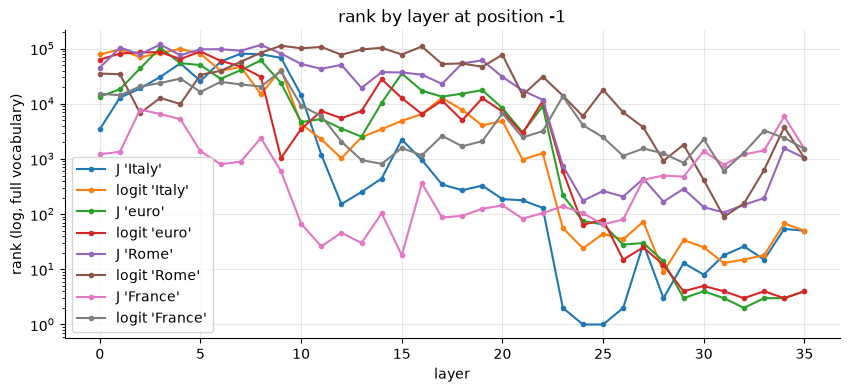

In [36]:
@torch.no_grad()
def explore(prompt, track=(), position=-1, top_n=8, layer_stride=None, continue_for=12):
    # Per-layer readout of both lenses at one position, the ranks of tracked words,
    # and what the model actually generates -- the three things needed to judge a lens.
    stride = layer_stride or LAYER_STRIDE
    layers = sorted({*range(0, model.n_layers, stride), model.n_layers - 1})
    jl_logits, ll_logits = jacobian_lens(model, lens, prompt), logit_lens(model, prompt)
    ids = model.encode(prompt)

    print(f"prompt   : {prompt!r}")
    print(f"tokens   : {[tokenizer.decode([i]) for i in ids[0].tolist()]}")
    print(f"readout  : position {position} = {tokenizer.decode([ids[0, position]])!r}")
    if continue_for:
        generated = hf_model.generate(ids, max_new_tokens=continue_for, do_sample=False,
                                      pad_token_id=tokenizer.pad_token_id)
        print(f"model says: {tokenizer.decode(generated[0, ids.shape[1]:], skip_special_tokens=True)!r}")

    rows = []
    for layer in layers:
        entry = {"layer": layer}
        for name, logits in (("J-lens", jl_logits), ("logit lens", ll_logits)):
            top = logits[layer, position].topk(top_n).indices.tolist()
            entry[name] = " ".join(repr(tokenizer.decode([i])) for i in top)
        rows.append(entry)
    print()
    display(pd.DataFrame(rows).set_index("layer"))

    if track:
        ranks = {}
        for word in track:
            ids_of_word = sorted(fuzzy_spelling_ids(tokenizer, word))
            if not ids_of_word:
                print(f"(skipping {word!r}: unscorable under fuzzy matching)")
                continue
            index = torch.tensor(ids_of_word, device=jl_logits.device)
            for name, logits in (("J", jl_logits), ("logit", ll_logits)):
                scores = logits[:, position]
                best = scores[:, index].max(-1).values
                ranks[f"{name} {word!r}"] = ((scores > best.unsqueeze(-1)).sum(-1) + 1).cpu().numpy()
        frame = pd.DataFrame(ranks, index=range(model.n_layers))
        frame.index.name = "layer"
        display(frame.loc[layers])
        axis = frame.plot(figsize=(10, 4), logy=True, marker=".")
        axis.set_ylabel("rank (log, full vocabulary)")
        axis.set_title(f"rank by layer at position {position}")
        axis.grid(alpha=0.3)
        axis.spines[["top", "right"]].set_visible(False)
        plt.show()


explore(PLAY_PROMPT, track=PLAY_TRACK, position=PLAY_POSITION, top_n=PLAY_TOP_N)

### And the same prompt as an interactive slice

Click any cell to pin that token and see its rank at every position and layer.

In [37]:
slice_page(PLAY_PROMPT, title="Playground", description=PLAY_PROMPT,
           track=tuple(PLAY_TRACK))

0.41 MB page, 81 tracked tokens


### A control: the lens should *not* be confident about nonsense

If a readout looks equally decisive on a prompt with no answer, it is reading the prompt's
surface form rather than a computation.

prompt   : 'Fact: The glorp of the frobnicated widget is'
tokens   : ['Fact', ':', ' The', ' gl', 'orp', ' of', ' the', ' fro', 'bn', 'icated', ' widget', ' is']
readout  : position -1 = ' is'


model says: " a measure of the widget's ability to"



,J-lens,logit lens
layer,,
0,' –' ' …\n\n' ' ….' '”.\n\n' ' .\n\n' '….\n\n'...,'/is' 'lington' 'いか' '館' 'abella' '该县' '紋' 'ot...
3,'”\n' '’.\n\n' '`.\n' '‘' '.”\n' '”.\n\n' '”\n...,'omers' 'antar' '-Sah' 'abella' '-roll' '행' '证...
6,'”。\n\n' '”，' '。\n\n' '，' '`.\n\n' '”的' '”.\n\...,'-vous' 'rael' 'ZW' 'rather' '个多' 'omers' '另一种...
9,' pakistan' ' muslim' ' .\n\n' ' ，' ' malaysia...,'功劳' '另一种' ' instrumental' 'omers' ' celebrate...
12,' �' ' \\`' '甚么' ' \\<^' ' \\<' '\\<^' '一个' ' ...,"'omers' '个多' '""label' ' 물론' '廳' 'acies' ' fool..."
15,' \\`' '甚么' '所谓' ' {@' ';$' ' ascii' ' /*#__' ...,'pus' '一个新的' 'Ŷ' '躁' 'acies' 'abilities' '的确' ...
18,' metaphor' ' metaph' ' metast' ' philosoph' '...,'omers' '的确' '岚' '陣' 'ón' ' indeed' 'óc' '_hat'
21,'哲学' ' philosophical' '量化' ' philosoph' ' meta...,'岚' 'omers' ' always' '鹩' '不完' 'ieri' ' often'...
24,' inherently' ' always' ' seldom' ' necessary'...,' always' ' often' ' typically' 'omers' ' desc...


,J 'Italy',logit 'Italy',J 'euro',logit 'euro'
layer,,,,
0,3765,68179,8912,78205
3,31199,82707,96261,97390
6,80565,124513,54475,63174
9,91401,113806,62923,65228
12,75628,34214,97615,85401
15,123694,62299,94626,17547
18,136777,41783,69232,21151
21,113193,95563,64715,77849
24,63167,87868,68650,94432


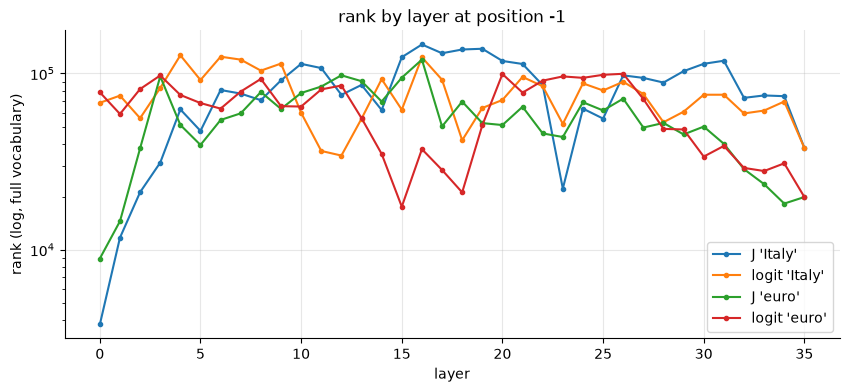

In [38]:
explore("Fact: The glorp of the frobnicated widget is",
        track=["Italy", "euro"], continue_for=8)